## 1. Install yolov10 and Import Dependencies

In [ ]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
print(torch.cuda.is_available())       # should be True
print(torch.cuda.device_count())       # should be 1
print(torch.cuda.get_device_name(0))   # should show your RTX 5060

True
1
NVIDIA GeForce RTX 5060 Laptop GPU


In [ ]:
!git clone https://github.com/THU-MIG/yolov10

fatal: destination path 'yolov10' already exists and is not an empty directory.


In [4]:
!cd yolov10

In [ ]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


### Libraies
* Torch: Will be used to load the YOLO model and make detection

* Matplotib: Will be used for visualising image

* Numpy: will be used for array transformation

* OpenCV: Help access the webcan and render feeds

In [6]:
from matplotlib import pyplot as plt
import cv2
from ultralytics import YOLO

## 2. Load Model

In [7]:
model = YOLO("yolov10n.pt")

In [ ]:
model.info()

YOLOv10n summary: 223 layers, 2,775,520 parameters, 0 gradients, 8.7 GFLOPs


(223, 2775520, 0, 8.7404288)

## 3. YOLOv10 Model Testing on Sample Image

In [9]:
image = 'https://jooinn.com/images/group-of-people-18.jpg'


Found https://jooinn.com/images/group-of-people-18.jpg locally at group-of-people-18.jpg
image 1/1 D:\SLIIT\2Y2S\AIML_Project_AI\group-of-people-18.jpg: 384x640 10 persons, 19.2ms
Speed: 1.9ms preprocess, 19.2ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(4992.5), np.float64(2808.5), np.float64(-0.5))

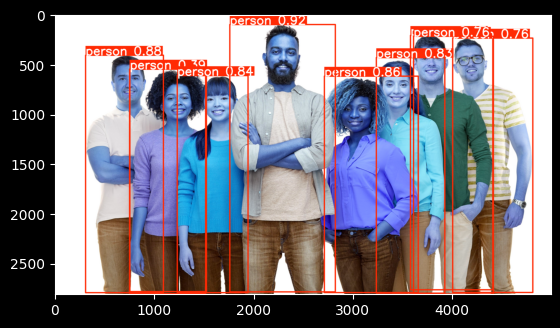

In [ ]:
# predict
results = model.predict(source=image)

# show
plt.imshow(results[0].plot())
plt.axis("on")

## 4. Real Time Detections

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()

    # Make detection
    results = model(frame)

    # cv2.imshow("yolo", frame)
    cv2.imshow("yolo", results[0].plot())

    if cv2.waitKey(10) & 0xff == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 1 umbrella, 20.8ms
Speed: 1.2ms preprocess, 20.8ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 10.3ms
Speed: 1.5ms preprocess, 10.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 6.7ms
Speed: 3.8ms preprocess, 6.7ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 6.8ms
Speed: 1.0ms preprocess, 6.8ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 6.3ms
Speed: 1.2ms preprocess, 6.3ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 6.6ms
Speed: 1.3ms preprocess, 6.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 7.9ms
Speed: 1.3ms preprocess, 7.9ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 umbrella, 6.5ms
Spee

## 5. Draw bounding using labelImg

* Upload images to labelImg

* Draw bounding boxes around objects

* Assign class labels (Drowsiness, Yawn, PhoneUse, Natural)

* Use the labeled data to train the AI model

## 6. Train model

* YOLO("yolov10m.pt") → loads pretrained model

* data="dataset.yaml" → where training images are, where labels are, class names

* epochs=10 → The model will study the entire dataset 80 times

* imgsz=320 → Resize every image to 320 × 320 pixels

* batch=16 → The model looks at 16 images at once before learning

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov10m.pt")

model.train(
    data="dataset.yaml",   # your dataset config
    epochs=10,             # number of training rounds
    imgsz=320,             # image size
    batch=16,              # batch size
    device=0,              # use your NVIDIA GPU
    workers=2              # reduces CPU load and keeps temps lower
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.10.10 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train21, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002753CFA2230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

## 7. Load Trained Model

In [6]:
from matplotlib import pyplot as plt
import cv2
from ultralytics import YOLO
import os

In [ ]:
model = YOLO("runs/detect/train21/weights/best.pt")

## 8. Evaluate

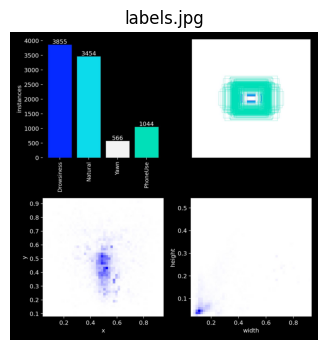

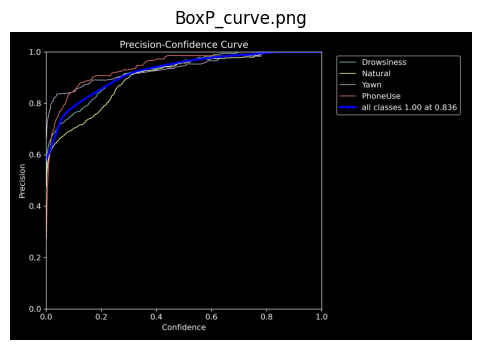

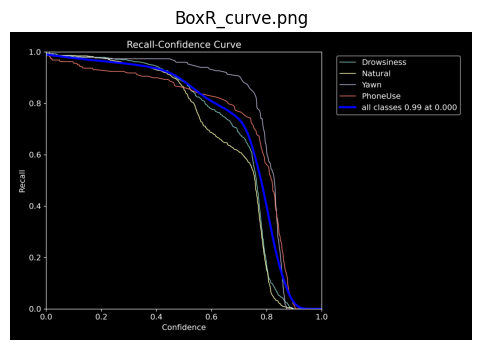

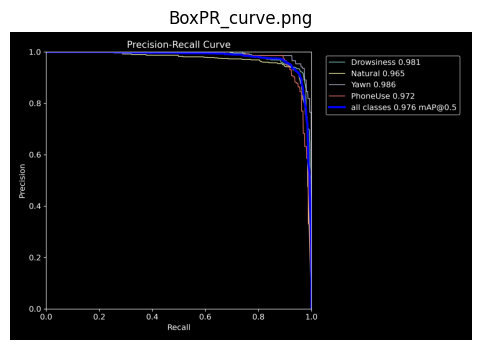

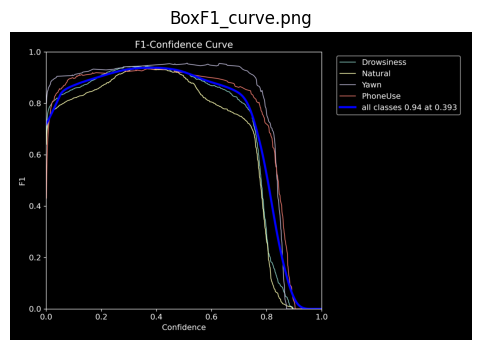

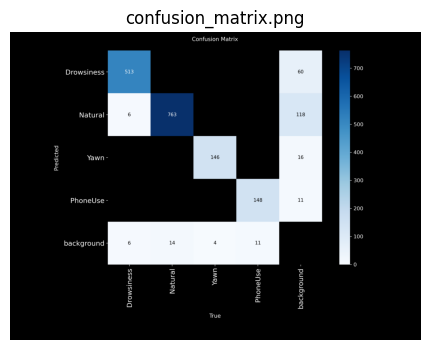

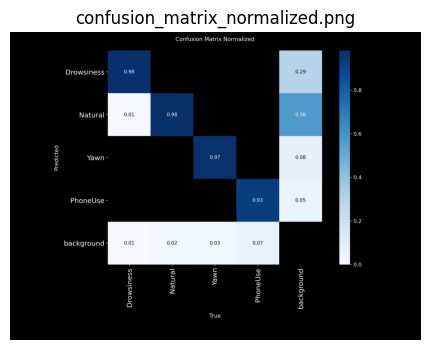

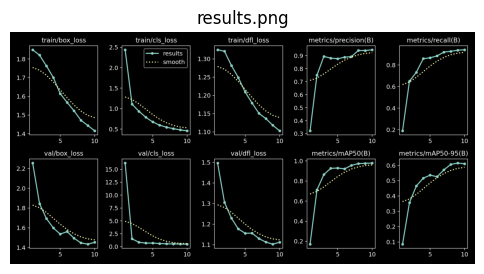

In [8]:
folder = "runs/detect/train21"

files = [
    "labels.jpg",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "results.png"
]

# show each image
for file in files:
    path = os.path.join(folder, file)

    if os.path.exists(path):
        img = cv2.imread(path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,4))
        plt.title(file)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.show()
    else:
        print(f" Not found: {file}")

## 9. Test trained model using pictures


image 1/1 d:\My_Projects\Driver_Behavior_Detection_Project\Driver_Behavior_Detection_AI\dataset\images\train\336078982_5932681210172690_8276381070486962044_n_mp4-95_jpg.rf.2e08dbcc31ef919e117f3b7ee7a117ea.jpg: 320x320 1 Drowsiness, 39.9ms
Speed: 1.0ms preprocess, 39.9ms inference, 0.2ms postprocess per image at shape (1, 3, 320, 320)


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

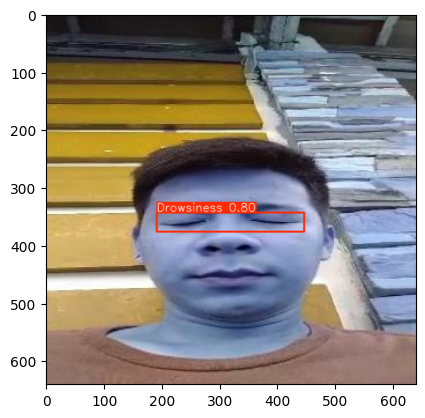

In [12]:
# predict
results = model.predict(source="dataset/images/train/336078982_5932681210172690_8276381070486962044_n_mp4-95_jpg.rf.2e08dbcc31ef919e117f3b7ee7a117ea.jpg")

# show
plt.imshow(results[0].plot())
plt.axis("on")

## 10. Test trained model using camera

In [10]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()

    # Make detection
    results = model(frame)

    # cv2.imshow("yolo", frame)
    cv2.imshow("yolo", results[0].plot())

    if cv2.waitKey(10) & 0xff == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


0: 256x320 (no detections), 63.4ms
Speed: 0.8ms preprocess, 63.4ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 64.7ms
Speed: 1.0ms preprocess, 64.7ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 34.6ms
Speed: 0.5ms preprocess, 34.6ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 32.2ms
Speed: 0.4ms preprocess, 32.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 34.8ms
Speed: 0.6ms preprocess, 34.8ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 30.9ms
Speed: 0.4ms preprocess, 30.9ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 31.9ms
Speed: 0.4ms preprocess, 31.9ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

0: 256x320 (no detections), 30.7ms
Speed: 0.4ms preprocess, 30.7ms i